<a href="https://colab.research.google.com/github/ashrithpatha/ASML_Project_and_Labs/blob/main/AIML_Module_01_Lab_01_Feature.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extracting features from data
Module 1, Lab 1

In [2]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=e29766abb87a1a588ade41078f809d093640b232849246f51c73d210f69519c3
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


Part 1: Features of text
How do we apply machine learning on text? We can't directly use the text as input to our algorithms. We need to convert them to features. In this notebook, we will explore a simple way of converting text to features.

Let us download a few documents off Wikipedia.

In [37]:
# ---------- English Topics ----------
topic1 = 'Car'
topic2 = 'Bike'

wikipedia.set_lang('en')

eng1 = wikipedia.page(topic1).content
eng2 = wikipedia.page(topic2).content


# ----- Car Article -----
print(topic1, "Article:")
print(eng1[:94])

print("Length of article:", len(eng1))

print("Does the word 'Car' appear in article?", "Car" in eng1)

text1 = eng1.lower()
print("Lowercase text sample:")
print(len(eng1))

print("\n")


# ----- Bike Article -----
print(topic2, "Article:")
print(eng2[:93])

print("Length of article:", len(eng2))

print("Does the word 'Bike' appear in article?", "Bike" in eng2)

text2 = eng2.lower()
print("Lowercase text sample:")
print(text2[:93])

print("\n")


# ---------- Hindi Topics ----------
topic1 = 'कार'
topic2 = 'मोटरसाइकिल'

wikipedia.set_lang('hi')

hin1 = wikipedia.page(topic1).content
hin2 = wikipedia.page(topic2).content


# ----- Hindi Car Article -----
print(topic1, "Article:")
print(hin1[:142])

print("\n")


# ----- Hindi Bike Article -----
print(topic2, "Article:")
print(hin2[:92])

Car Article:
The cat (Felis catus), also called domestic cat and house cat, is a small carnivorous mammal. 
Length of article: 50316
Does the word 'Car' appear in article? True
Lowercase text sample:
the cat (felis catus), also called domestic cat and house cat, is a small carnivorous mammal. 


Bike Article:
In English, the word like has a very wide range of uses, both conventional and non-standard. 
Length of article: 9532
Does the word 'Bike' appear in article? False
Lowercase text sample:
in english, the word like has a very wide range of uses, both conventional and non-standard. 


कार Article:
मोटरवाहन , कार, मोटरकार या ऑटोमोबाइल एक पहियों वाला वाहन है, जो यात्रियों के परिवहन के काम आता है; और जो अपना इंजन या मोटर भी स्वयं उठाता है। 


मोटरसाइकिल Article:
मोटरसाइकिल (या मोटरबाइक) आंतरिक दहन इंजन से उर्जा प्राप्त करने वाले एक दो चक्के का वाहन है। 


We need to clean this up a bit. Let us remove all the special characters and keep only 26 letters and space. Note that this will remove accented characters in French also. We are also removing all the numbers and spaces. So this is not an ideal solution.

In [60]:
def cleanup(text):
    text = text.lower()
    text = re.sub('[^a-z\u0900-\u097F ]+', '', text)
    return text

In [61]:
eng1_clean = cleanup(eng1)
eng2_clean = cleanup(eng2)
hin1_clean = cleanup(hin1)
hin2_clean = cleanup(hin2)

# ---------- English Article 1 ----------
print("Original English length:", len(eng1))
print("Cleaned English length:", len(eng1_clean))

print("\nOriginal English text:")
print(eng1[:200])

print("\nCleaned English text:")
print(eng1_clean[:200])

print("\n")


# ---------- Hindi Article 1 ----------
print("Original Hindi length:", len(hin1))
print("Cleaned Hindi length:", len(hin1_clean))

print("\nOriginal Hindi text:")
print(hin1[:200])

print("\nCleaned Hindi text:")
print(hin1_clean[:200])

print("\n")


# ---------- English Article 2 ----------
print("Original English length:", len(eng2))
print("Cleaned English length:", len(eng2_clean))

print("\nOriginal English text:")
print(eng2[:200])

print("\nCleaned English text:")
print(eng2_clean[:200])

print("\n")


# ---------- Hindi Article 2 ----------
print("Original Hindi length:", len(hin2))
print("Cleaned Hindi length:", len(hin2_clean))

print("\nOriginal Hindi text:")
print(hin2[:200])

print("\nCleaned Hindi text:")
print(hin2_clean[:200])

Original English length: 50316
Cleaned English length: 48081

Original English text:
The cat (Felis catus), also called domestic cat and house cat, is a small carnivorous mammal. It is an obligate carnivore, requiring a predominantly meat-based diet. Its retractable claws are adapted 

Cleaned English text:
the cat felis catus also called domestic cat and house cat is a small carnivorous mammal it is an obligate carnivore requiring a predominantly meatbased diet its retractable claws are adapted to killi


Original Hindi length: 32426
Cleaned Hindi length: 30596

Original Hindi text:
मोटरवाहन , कार, मोटरकार या ऑटोमोबाइल एक पहियों वाला वाहन है, जो यात्रियों के परिवहन के काम आता है; और जो अपना इंजन या मोटर भी स्वयं उठाता है। इस शब्द की अधिकांश परिभाषाओं के अनुसार मोटरवाहन मुख्य रूप 

Cleaned Hindi text:
मोटरवाहन  कार मोटरकार या ऑटोमोबाइल एक पहियों वाला वाहन है जो यात्रियों के परिवहन के काम आता है और जो अपना इंजन या मोटर भी स्वयं उठाता है। इस शब्द की अधिकांश परिभाषाओं के अनुसार मोटरवाहन म

Now let us calculate the frequency of the character n-grams. N-grams are groups of characters of size n. A unigram is a single character and a bigram is a group of two characters and so on.

Let us count the frequency of each character in a text and plot it in a histogram.

In [39]:
# convert a tuple of characters to a string
def tuple2string(tup):
  st = ''
  for ii in tup:
    st = st + ii
  return st

# convert a tuple of tuples to a list of strings
def key2string(keys):
  return [tuple2string(i) for i in keys]

# plot the histogram
def plothistogram(ngram):
  keys = key2string(ngram.keys())
  values = list(ngram.values())

  # sort the keys in alphabetic order
  combined = zip(keys, values)
  zipped_sorted = sorted(combined, key=lambda x: x[0])
  keys, values = map(list, zip(*zipped_sorted))
  plt.bar(keys, values)

Let us compare the histograms of English pages and Hindi pages. Can you spot a difference?

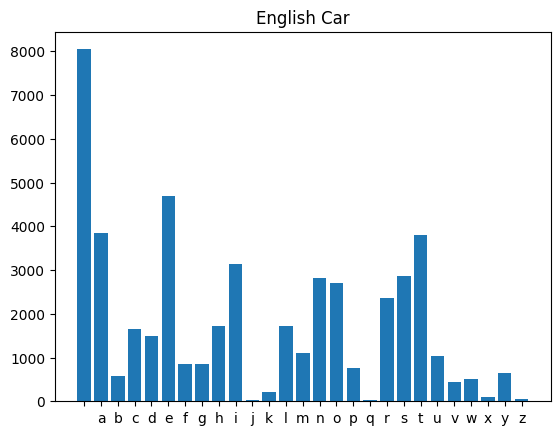

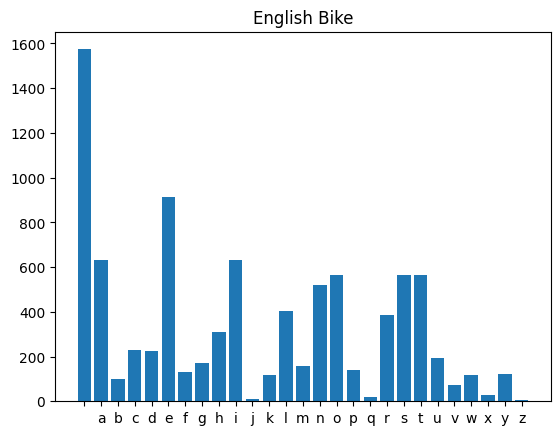

In [71]:
# ---------- English Unigram Histogram ----------

unigram_eng1 = Counter(ngrams(eng1_clean,1))
plothistogram(unigram_eng1)
plt.title('English Car')
plt.show()

unigram_eng2 = Counter(ngrams(eng2_clean,1))
plothistogram(unigram_eng2)
plt.title('English Bike')
plt.show()

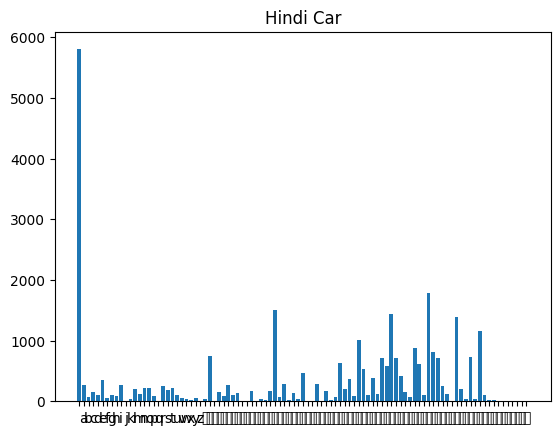

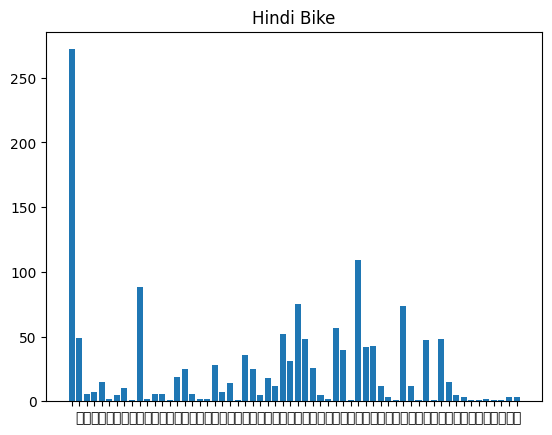

In [72]:
# ---------- Hindi Unigram Histogram ----------

unigram_hin1 = Counter(ngrams(hin1_clean,1))
plothistogram(unigram_hin1)
plt.title('Hindi Car')
plt.show()

unigram_hin2 = Counter(ngrams(hin2_clean,1))
plothistogram(unigram_hin2)
plt.title('Hindi Bike')
plt.show()

We can see that the unigrams for Hindi and English are very similar. So this is not a good feature if we want to distinguish between English and French. Let us look at bigrams.

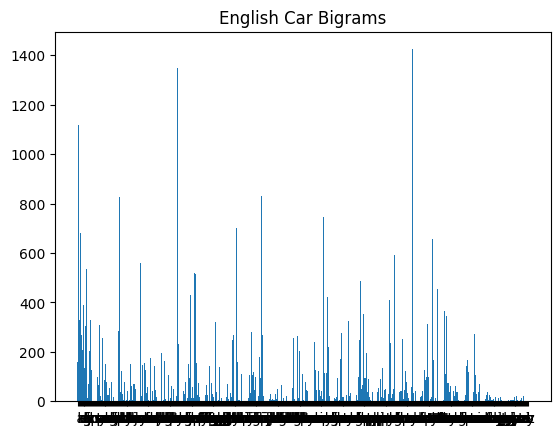

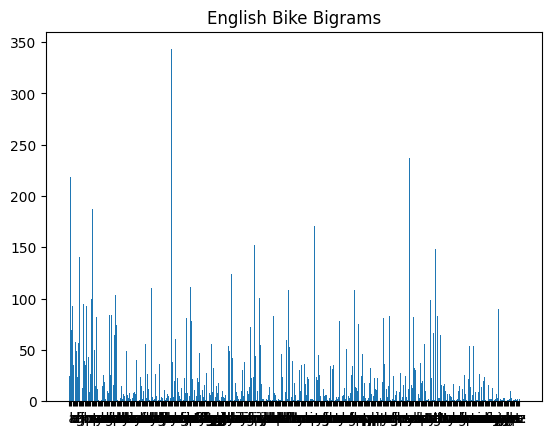

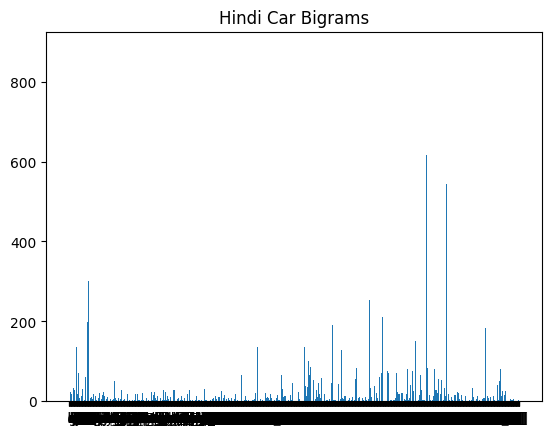

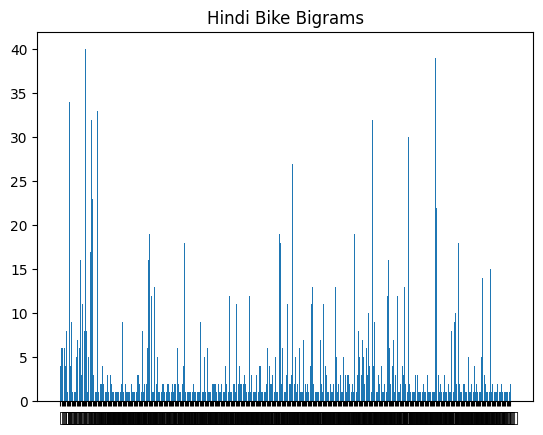

In [73]:
# ---------- English Bigram Histogram ----------

bigram_eng1 = Counter(ngrams(eng1_clean,2))
plothistogram(bigram_eng1)
plt.title('English Car Bigrams')
plt.show()

bigram_eng2 = Counter(ngrams(eng2_clean,2))
plothistogram(bigram_eng2)
plt.title('English Bike Bigrams')
plt.show()

# ---------- Hindi Bigram Histogram ----------

bigram_hin1 = Counter(ngrams(hin1_clean,2))
plothistogram(bigram_hin1)
plt.title('Hindi Car Bigrams')
plt.show()

bigram_hin2 = Counter(ngrams(hin2_clean,2))
plothistogram(bigram_hin2)
plt.title('Hindi Bike Bigrams')
plt.show()

Another way to visualize bigrams is to use a 2-dimensional graph.

In [74]:
def plotbihistogram(ngram):
  freq = np.zeros((26,26))
  for ii in range(26):
    for jj in range(26):
      freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]
  plt.imshow(freq, cmap = 'jet')
  return freq

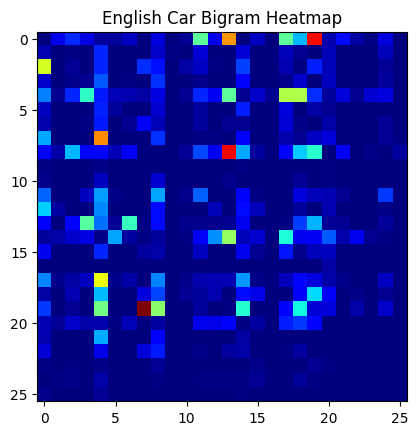

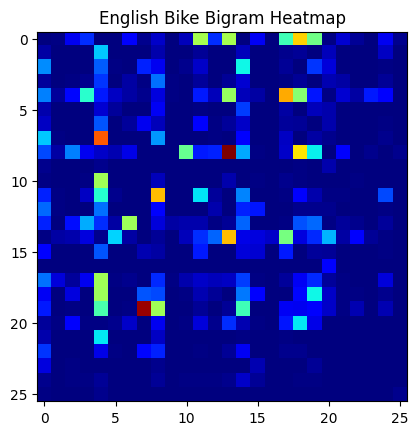

In [75]:
# ---------- English Car Bigram Heatmap ----------

bigram_eng1 = Counter(ngrams(eng1_clean,2))

plt.figure()
plotbihistogram(bigram_eng1)
plt.title("English Car Bigram Heatmap")
plt.show()

# ---------- English Bike Bigram Heatmap ----------

bigram_eng2 = Counter(ngrams(eng2_clean,2))

plt.figure()
plotbihistogram(bigram_eng2)
plt.title("English Bike Bigram Heatmap")
plt.show()

In [76]:
def plotbihistogram_hindi(ngram):

    # collect all characters appearing in bigrams
    chars = sorted(set([c for pair in ngram.keys() for c in pair]))

    size = len(chars)
    freq = np.zeros((size, size))

    char_index = {c:i for i,c in enumerate(chars)}

    for (c1,c2), count in ngram.items():
        i = char_index[c1]
        j = char_index[c2]
        freq[i,j] = count

    plt.imshow(freq, cmap='jet')
    plt.colorbar()
    plt.xticks(range(size), chars, rotation=90)
    plt.yticks(range(size), chars)

    return freq

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2305 (\N{DEVANAGARI SIGN CANDRABINDU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2307 (\N{DEVANAGARI SIGN VISARGA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

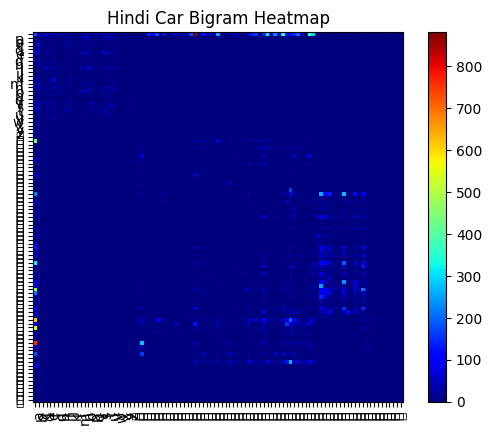

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2311 (\N{DEVANAGARI LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/p

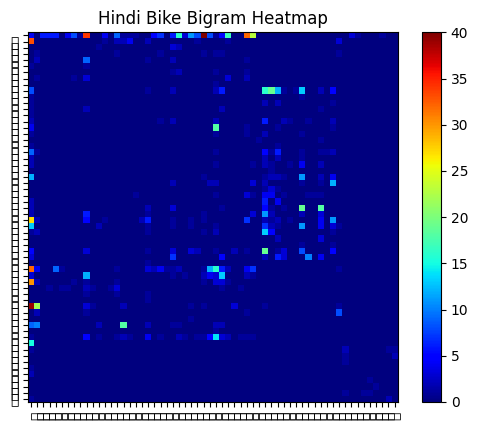

In [78]:
bigram_hin1 = Counter(ngrams(hin1_clean,2))
bigram_hin2 = Counter(ngrams(hin2_clean,2))

# ---------- Hindi Car Bigram Heatmap ----------
plt.figure()
plotbihistogram_hindi(bigram_hin1)
plt.title("Hindi Car Bigram Heatmap")
plt.show()

# ---------- Hindi Bike Bigram Heatmap ----------
plt.figure()
plotbihistogram_hindi(bigram_hin2)
plt.title("Hindi Bike Bigram Heatmap")
plt.show()

In [104]:
from IPython.core.debugger import set_trace

def ind2tup(ind):
  ind = int(ind)
  i = int(ind/26)
  j = int(ind%26)
  return (chr(ord('a')+i), chr(ord('a')+j))

def ShowTopN(bifreq, n=10):
  f = bifreq.flatten()
  arg = np.argsort(-f)
  for ii in range(n):
    print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')

Let us look at the top 10 ngrams for each text.


English Car:
('t', 'h') : 922.0
('i', 'n') : 829.0
('a', 't') : 826.0
('h', 'e') : 701.0
('a', 'n') : 688.0
('r', 'e') : 590.0
('c', 'a') : 561.0
('e', 'r') : 520.0
('e', 's') : 516.0
('o', 'n') : 487.0

English Bike:
('i', 'n') : 152.0
('t', 'h') : 148.0
('h', 'e') : 124.0
('e', 'r') : 111.0
('l', 'i') : 108.0
('o', 'n') : 108.0
('a', 's') : 104.0
('i', 's') : 101.0
('a', 'n') : 84.0
('a', 'l') : 84.0

Hindi Car:
(' ', 'क') : 881
('े', ' ') : 755
('ा', ' ') : 617
('ी', ' ') : 545
('र', ' ') : 470
('ं', ' ') : 433
(' ', 'स') : 385
(' ', 'म') : 337
('न', ' ') : 322
(' ', 'प') : 316

Hindi Bike:
(' ', 'म') : 40
('े', ' ') : 39
(' ', 'क') : 34
('ं', ' ') : 33
('ा', ' ') : 32
(' ', 'स') : 32
('ी', ' ') : 30
('र', ' ') : 27
(' ', 'ह') : 23
('े', 'ं') : 22


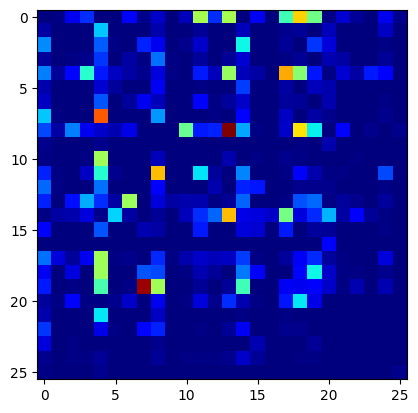

In [80]:
# English Car
bigram_eng1 = Counter(ngrams(eng1_clean,2))
bieng1 = plotbihistogram(bigram_eng1)

# English Bike
bigram_eng2 = Counter(ngrams(eng2_clean,2))
bieng2 = plotbihistogram(bigram_eng2)

print('\nEnglish Car:')
ShowTopN(bieng1)

print('\nEnglish Bike:')
ShowTopN(bieng2)

print('\nHindi Car:')
for bigram, count in bigram_hin1.most_common(10):
    print(f'{bigram} : {count}')

print('\nHindi Bike:')
for bigram, count in bigram_hin2.most_common(10):
    print(f'{bigram} : {count}')


In [82]:
# ---------- Trigram Experiment (n = 3) ----------

tri_eng1 = Counter(ngrams(eng1_clean,3))
tri_eng2 = Counter(ngrams(eng2_clean,3))

print("Top 10 English Car Trigrams")
for trigram, count in tri_eng1.most_common(10):
    print(trigram, ":", count)

print("\nTop 10 English Bike Trigrams")
for trigram, count in tri_eng2.most_common(10):
    print(trigram, ":", count)

Top 10 English Car Trigrams
(' ', 't', 'h') : 698
('t', 'h', 'e') : 600
(' ', 'c', 'a') : 436
('c', 'a', 't') : 400
('h', 'e', ' ') : 398
(' ', 'a', 'n') : 359
('n', 'd', ' ') : 339
('t', 's', ' ') : 334
('e', 'd', ' ') : 323
('n', 'g', ' ') : 314

Top 10 English Bike Trigrams
(' ', 't', 'h') : 112
('t', 'h', 'e') : 94
('h', 'e', ' ') : 83
('a', 's', ' ') : 83
(' ', 'i', 'n') : 77
('l', 'i', 'k') : 69
('i', 'k', 'e') : 68
(' ', 'l', 'i') : 67
('i', 'n', ' ') : 61
('k', 'e', ' ') : 61


In [81]:
# ---------- Hindi Trigram Experiment ----------

tri_hin1 = Counter(ngrams(hin1_clean,3))
tri_hin2 = Counter(ngrams(hin2_clean,3))

print("Top 10 Hindi Car Trigrams")
for trigram, count in tri_hin1.most_common(10):
    print(trigram, ":", count)

print("\nTop 10 Hindi Bike Trigrams")
for trigram, count in tri_hin2.most_common(10):
    print(trigram, ":", count)

Top 10 Hindi Car Trigrams
('क', 'े', ' ') : 248
('े', 'ं', ' ') : 238
(' ', 'क', 'े') : 222
('म', 'े', 'ं') : 211
(' ', 'म', 'े') : 201
('न', 'े', ' ') : 184
('य', 'ा', ' ') : 181
(' ', 'क', 'ा') : 176
(' ', 'औ', 'र') : 170
('औ', 'र', ' ') : 170

Top 10 Hindi Bike Trigrams
('े', 'ं', ' ') : 21
('म', 'ो', 'ट') : 18
('ो', 'ट', 'र') : 18
(' ', 'म', 'े') : 18
(' ', 'म', 'ो') : 17
('म', 'े', 'ं') : 16
('क', 'े', ' ') : 13
(' ', 'स', 'ा') : 12
('क', 'ि', 'ल') : 11
('क', 'ी', ' ') : 11


In [83]:
# ---------- General N-gram Function ----------

def show_top_ngrams(text, n=4, top=10):

    ngram_freq = Counter(ngrams(text, n))

    print(f"Top {top} {n}-grams:")

    for gram, count in ngram_freq.most_common(top):
        print(gram, ":", count)

In [85]:
show_top_ngrams(eng1_clean,4)
show_top_ngrams(eng1_clean,5)
show_top_ngrams(hin1_clean,3)

Top 10 4-grams:
(' ', 't', 'h', 'e') : 527
('t', 'h', 'e', ' ') : 392
(' ', 'c', 'a', 't') : 336
('i', 'n', 'g', ' ') : 298
('a', 'n', 'd', ' ') : 288
(' ', 'a', 'n', 'd') : 273
(' ', 'o', 'f', ' ') : 245
(' ', 't', 'o', ' ') : 240
('a', 't', 's', ' ') : 217
('c', 'a', 't', 's') : 213
Top 10 5-grams:
(' ', 't', 'h', 'e', ' ') : 380
(' ', 'a', 'n', 'd', ' ') : 273
('c', 'a', 't', 's', ' ') : 210
(' ', 'c', 'a', 't', 's') : 200
(' ', 'c', 'a', 't', ' ') : 117
(' ', 'a', 'r', 'e', ' ') : 101
('t', 'i', 'o', 'n', ' ') : 101
('a', 't', 'i', 'o', 'n') : 97
('n', ' ', 't', 'h', 'e') : 80
('s', ' ', 't', 'h', 'e') : 79
Top 10 3-grams:
('क', 'े', ' ') : 248
('े', 'ं', ' ') : 238
(' ', 'क', 'े') : 222
('म', 'े', 'ं') : 211
(' ', 'म', 'े') : 201
('न', 'े', ' ') : 184
('य', 'ा', ' ') : 181
(' ', 'क', 'ा') : 176
(' ', 'औ', 'र') : 170
('औ', 'र', ' ') : 170


Observations from the Experiment

1.We first collected text data from Wikipedia for different topics such as Car and Bike in English and कार and मोटरसाइकिल in Hindi.

2.The text data was cleaned and preprocessed by converting all characters to lowercase and removing unnecessary symbols, numbers, and punctuation.

3.This preprocessing step helped standardize the text and made it suitable for n-gram analysis.

4.We then generated character n-grams from the cleaned text.

Unigrams (n = 1) represent single characters.

Bigrams (n = 2) represent pairs of characters.

5.We calculated the frequency of each unigram and bigram using the Counter function.

6.These frequencies were visualized using histograms, which helped us observe how often different characters or character pairs occur in the text.

7.The unigram histograms for articles written in the same language appeared very similar, even though the topics were different.

8.This shows that unigrams capture general language characteristics rather than topic-specific information.

9.We then examined bigram frequencies and visualized them using histograms and heatmaps.

10.The bigram patterns for texts written in the same language were also similar, but they differed significantly between different languages (English vs Hindi).

11.This indicates that bigram frequencies capture language structure, such as common character combinations.

12.Therefore, bigram frequency is a useful feature for distinguishing languages, but it is not effective for distinguishing topics within the same language.

13.Through this experiment, we successfully converted a high-dimensional input (raw text) into numerical features.

14.Specifically:

Unigram representation → 26 dimensions (one for each character in the English alphabet).

Bigram representation → 26 × 26 = 676 dimensions, representing all possible character pairs.

15.These numerical representations can be used as features in machine learning models for tasks such as language detection or text classification.

Part 2: Written numbers
We will use a subset of the MNIST dataset. Each input character is represented in a 28*28 array. Let us see if we can extract some simple features from these images which can help us distinguish between the digits.

Load the dataset:

In [86]:
from keras.datasets import mnist

(train_x, train_y), (test_x, test_y) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Extract a subset of the data for our experiment:

In [87]:
no3 = train_x[train_y==3,:,:]
no8 = train_x[train_y==8,:,:]

Let us visualize a few images here:

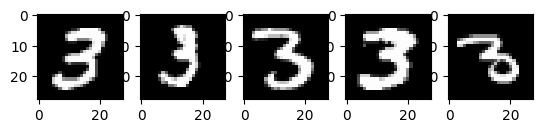

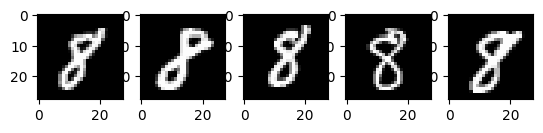

In [88]:
# Show first 5 images of digit 3
for ii in range(5):
    plt.subplot(1,5,ii+1)
    plt.imshow(no3[ii,:,:], cmap='gray')
plt.show()

# Show first 5 images of digit 8
for ii in range(5):
    plt.subplot(1,5,ii+1)
    plt.imshow(no8[ii,:,:], cmap='gray')
plt.show()

suNow, let us start with a simple feature: the sum of all pixels and see how good this feature is.

In [90]:
# Sum of pixels feature for digits 3 and 8

sum3 = np.sum(no3 > 0, (1,2))   # count pixels that are not zero
sum8 = np.sum(no8 > 0, (1,2))   # count pixels that are not zero

Let us visualize how good this feature is: (X-axis is mean, y-axis is the digit)

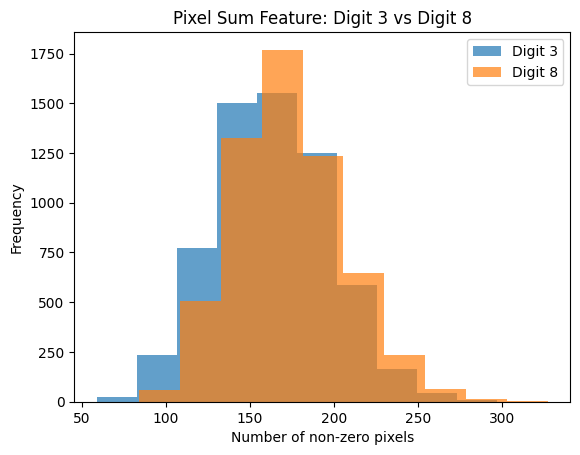

In [91]:
# Visualize the pixel sum feature

plt.hist(sum3, alpha=0.7, label="Digit 3")
plt.hist(sum8, alpha=0.7, label="Digit 8")

plt.xlabel("Number of non-zero pixels")
plt.ylabel("Frequency")
plt.title("Pixel Sum Feature: Digit 3 vs Digit 8")
plt.legend()

plt.show()

We can already see that this feature separates the two classes quite well.

Let us look at another, more complicated feature. We will count the number black pixels that are surrounded on four sides by non-black pixels, or "hole pixels".

In [92]:
def cumArray(img):
  img2 = img.copy()
  for ii in range(1, img2.shape[1]):
    img2[ii,:] = img2[ii,:] + img2[ii-1,:]  # for every row, add up all the rows above it.
  img2 = img2>0
  return img2

def getHolePixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  hole = hull & ~ (img>0) # remove the original digit to leave behind the holes
  return hole

Visualize a few:

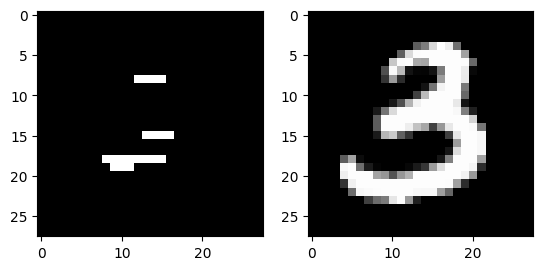

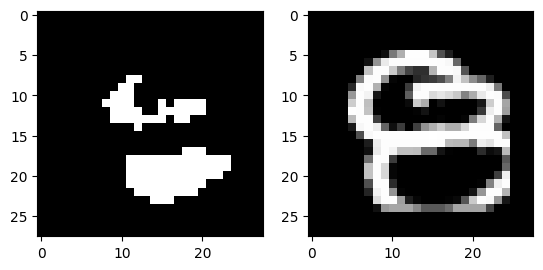

In [93]:
imgs = [no3[456,:,:], no8[456,:,:]]

for img in imgs:
    plt.subplot(1,2,1)
    plt.imshow(getHolePixels(img), cmap='gray')

    plt.subplot(1,2,2)
    plt.imshow(img, cmap='gray')

    plt.show()

Now let us plot the number of hole pixels and see how this feature behaves

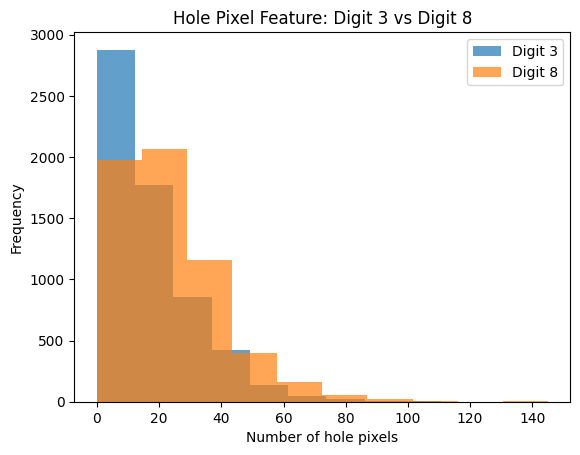

In [94]:
# Compute hole pixels feature

hole3 = np.array([getHolePixels(i).sum() for i in no3])
hole8 = np.array([getHolePixels(i).sum() for i in no8])


# Plot histogram

plt.hist(hole3, alpha=0.7, label="Digit 3")
plt.hist(hole8, alpha=0.7, label="Digit 8")

plt.xlabel("Number of hole pixels")
plt.ylabel("Frequency")
plt.title("Hole Pixel Feature: Digit 3 vs Digit 8")
plt.legend()

plt.show()

This feature works even better to distinguish between Three and Eight.

Now let us try the number of pixels in the 'hull' or the number with the holes filled in:



In [95]:
def getHullPixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  return hull

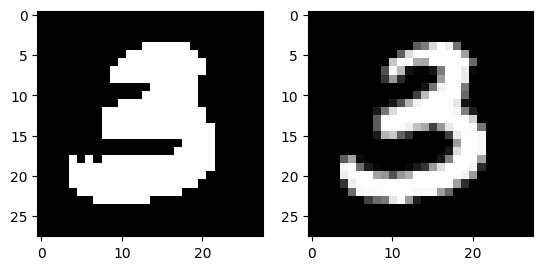

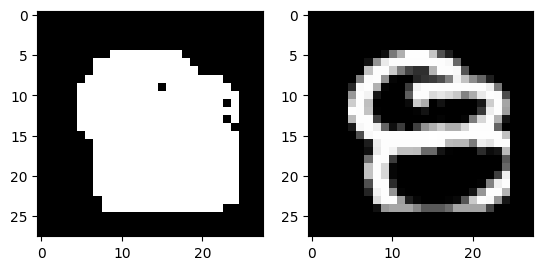

In [96]:
imgs = [no3[456,:,:], no8[456,:,:]]

for img in imgs:
    plt.subplot(1,2,1)
    plt.imshow(getHullPixels(img), cmap='gray')

    plt.subplot(1,2,2)
    plt.imshow(img, cmap='gray')

    plt.show()

Plotting the number of hull pixels versus the digit:

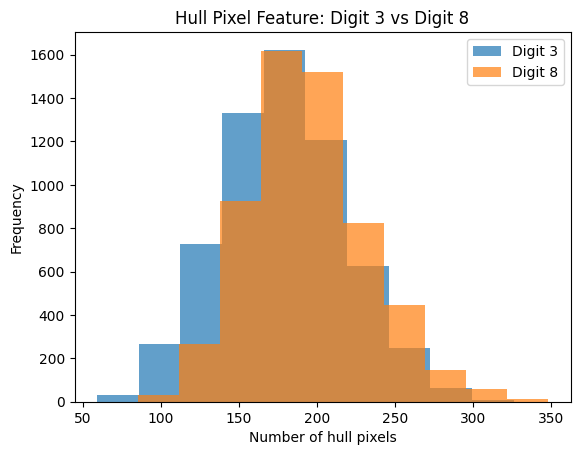

In [98]:
# Compute hull pixel feature

hull3 = np.array([getHullPixels(i).sum() for i in no3])
hull8 = np.array([getHullPixels(i).sum() for i in no8])


# Plot histogram

plt.hist(hull3, alpha=0.7, label="Digit 3")
plt.hist(hull8, alpha=0.7, label="Digit 8")

plt.xlabel("Number of hull pixels")
plt.ylabel("Frequency")
plt.title("Hull Pixel Feature: Digit 3 vs Digit 8")
plt.legend()

plt.show()

Let us try one more feature, where we look at the number of boundary pixels in each image.

In [99]:
def minus(a, b):
  return a & ~ b

def getBoundaryPixels(img):
  img = img.copy()>0  # binarize the image
  rshift = np.roll(img, 1, 1)
  lshift = np.roll(img, -1 ,1)
  ushift = np.roll(img, -1, 0)
  dshift = np.roll(img, 1, 0)
  boundary = minus(img, rshift) | minus(img, lshift) | minus(img, ushift) | minus(img, dshift)
  return boundary

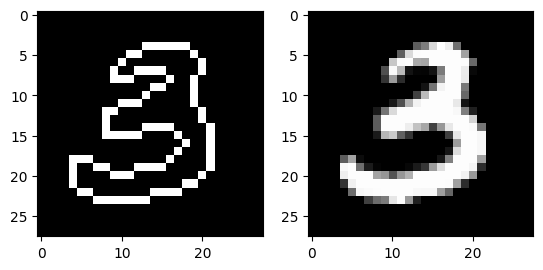

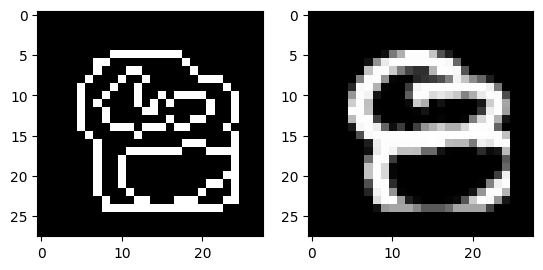

In [100]:
imgs = [no3[456,:,:], no8[456,:,:]]

for img in imgs:
    plt.subplot(1,2,1)
    plt.imshow(getBoundaryPixels(img), cmap='gray')

    plt.subplot(1,2,2)
    plt.imshow(img, cmap='gray')

    plt.show()

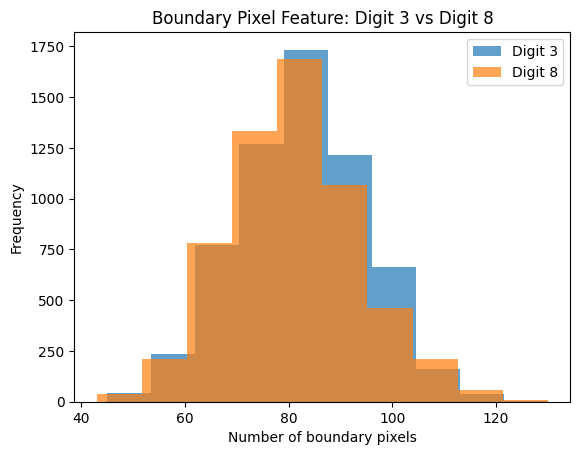

In [101]:
# Compute boundary pixel feature

bound3 = np.array([getBoundaryPixels(i).sum() for i in no3])
bound8 = np.array([getBoundaryPixels(i).sum() for i in no8])


# Plot histogram

plt.hist(bound3, alpha=0.7, label="Digit 3")
plt.hist(bound8, alpha=0.7, label="Digit 8")

plt.xlabel("Number of boundary pixels")
plt.ylabel("Frequency")
plt.title("Boundary Pixel Feature: Digit 3 vs Digit 8")
plt.legend()

plt.show()

What will happen if we plot two features together?

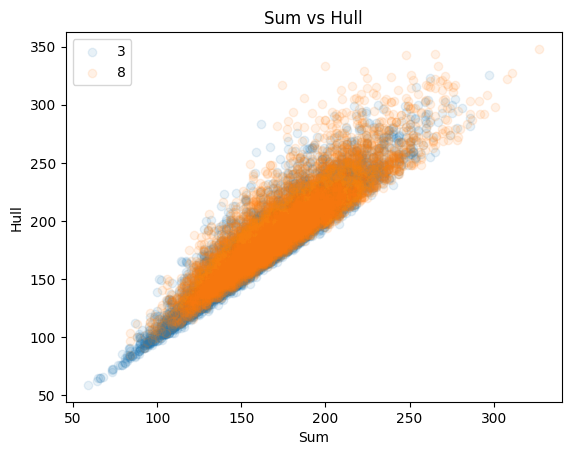

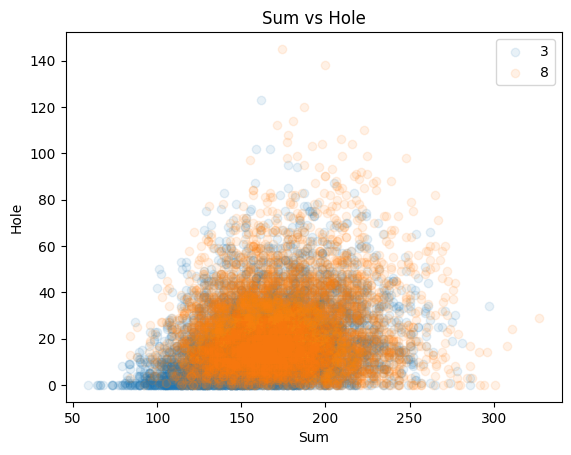

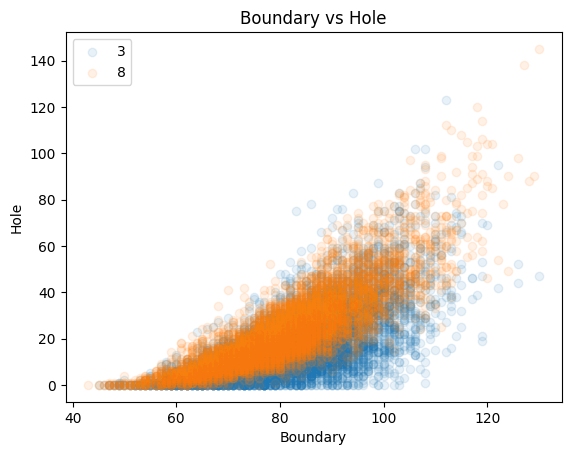

In [102]:
# ---------- Feature Comparison Scatter Plots ----------

# 1️⃣ Sum vs Hull
plt.figure()

plt.scatter(sum3, hull3, alpha=0.1)
plt.scatter(sum8, hull8, alpha=0.1)

plt.xlabel('Sum')
plt.ylabel('Hull')
plt.legend(['3', '8'])
plt.title('Sum vs Hull')

plt.show()


# 2️⃣ Sum vs Hole
plt.figure()

plt.scatter(sum3, hole3, alpha=0.1)
plt.scatter(sum8, hole8, alpha=0.1)

plt.xlabel('Sum')
plt.ylabel('Hole')
plt.legend(['3', '8'])
plt.title('Sum vs Hole')

plt.show()


# 3️⃣ Boundary vs Hole
plt.figure()

plt.scatter(bound3, hole3, alpha=0.1)
plt.scatter(bound8, hole8, alpha=0.1)

plt.xlabel('Boundary')
plt.ylabel('Hole')
plt.legend(['3', '8'])
plt.title('Boundary vs Hole')

plt.show()

Now let us try plotting 3 features together.

In [103]:
import pandas as pd
import plotly.express as px
import numpy as np

# Class labels
cl3 = ['class 3'] * len(sum3)
cl8 = ['class 8'] * len(sum8)

# Create dataframe
df = pd.DataFrame(
    list(zip(
        np.concatenate((hole3, hole8)),
        np.concatenate((sum3, sum8)),
        np.concatenate((bound3, bound8)),
        np.concatenate((cl3, cl8))
    )),
    columns=['Hole', 'Sum', 'Boundary', 'Class']
)

# Display first rows
df.head()

# 3D scatter plot
fig = px.scatter_3d(
    df,
    x='Hole',
    y='Sum',
    z='Boundary',
    color='Class',
    opacity=0.1
)

fig.show()

1️⃣ Which is the best combination of features?

The best combination is Hole pixels + Boundary pixels (or Sum + Hole).

Reason:

Digits with loops (0, 6, 8, 9) have more hole pixels.

Digits with complex shapes have more boundary pixels.

When these two features are combined, the classes become well separated in the feature space.

Example from experiment:

Digit	Hole	Boundary
3	low	medium
8	high	high

Thus the clusters become easier to distinguish.

2️⃣ How would you test or visualize four or more features?

When features are more than 3, visualization becomes difficult. We can use:

Methods

Pairwise scatter plots

Plot features two at a time.

3D scatter plots

Use three features together.

Dimensionality reduction techniques

PCA (Principal Component Analysis)

t-SNE

UMAP

Parallel coordinate plots

These techniques help visualize high-dimensional feature spaces.

3️⃣ Can you come up with your own features?

Yes. Possible features include:

Example features

Width of digit

number of pixels across.

Height of digit

Aspect ratio

width / height

Center of mass

average position of pixels.

Stroke thickness

Number of connected components

Curvature of edges

These features can help distinguish digits more effectively.

4️⃣ Will these features work for different classes other than 0 and 1?

Yes, but performance depends on the digits.

Examples:

Digits	Easy to distinguish?	Reason
1 vs 0	Very easy	hole difference
3 vs 8	Easy	hole + boundary
5 vs 6	harder	shapes similar
4 vs 9	harder	similar boundaries

So some classes may require more complex features.

5️⃣ What happens if we take more than two classes at a time?

If we include multiple classes:

Example:

0,1,2,3,4,5,6,7,8,9

Then:

clusters become more complex

feature overlap increases

classification becomes harder.

To handle this we may need:

more features

machine learning models

Example models:

Logistic Regression

SVM

Decision Trees

Neural Networks

🧠 Final conclusion

From the experiment we learned that:

Raw images (28×28 = 784 dimensions) can be converted into simple features.

Features like sum, hole pixels, hull pixels, and boundary pixels help distinguish digits.

Combining multiple features improves classification.

Feature extraction reduces dimensionality and simplifies learning.